In [21]:
import matplotlib.pyplot as plt
import numpy as np


def plot_waveform_scores_expected_analytic(waveform, scores, expected_analytic):
    waveform_normalized = waveform / np.std(waveform)
    abs_scores = np.abs(scores)
    normalized_expected_signal = expected_analytic / np.std(expected_analytic)

    plt.figure(figsize=(20, 10))
    plt.plot(
        waveform_normalized[
            np.argmax(abs_scores) - normalized_expected_signal.shape[0] // 2 :: 10
        ],
        label="waveform",
    )
    plt.plot(abs_scores[::10], label="scores")
    plt.plot(normalized_expected_signal[::10], label="expected analytic")
    plt.xlim([0, 1000])
    plt.legend()


debug_data: dict[str, tuple] = {
    "no-whatsapp": (
        np.load("../../output/waveform.npy"),
        np.load("../../output/scores.npy"),
        np.load("../../output/expected_analytic.npy"),
    ),
    "whatsapp-detected": (
        np.load("../../output/waveform2.npy"),
        np.load("../../output/scores2.npy"),
        np.load("../../output/expected_analytic2.npy"),
    ),
    "whatsapp-not-detected": (
        np.load("../../output/waveform_not_detected.npy"),
        np.load("../../output/scores_not_detected.npy"),
        np.load("../../output/expected_analytic_not_detected.npy"),
    ),
}

# Senza WhatsApp
Decoding senza il passaggio per WhatsApp, direttamente dal file generato. Questo grafico rappresenta la detection del preambolo

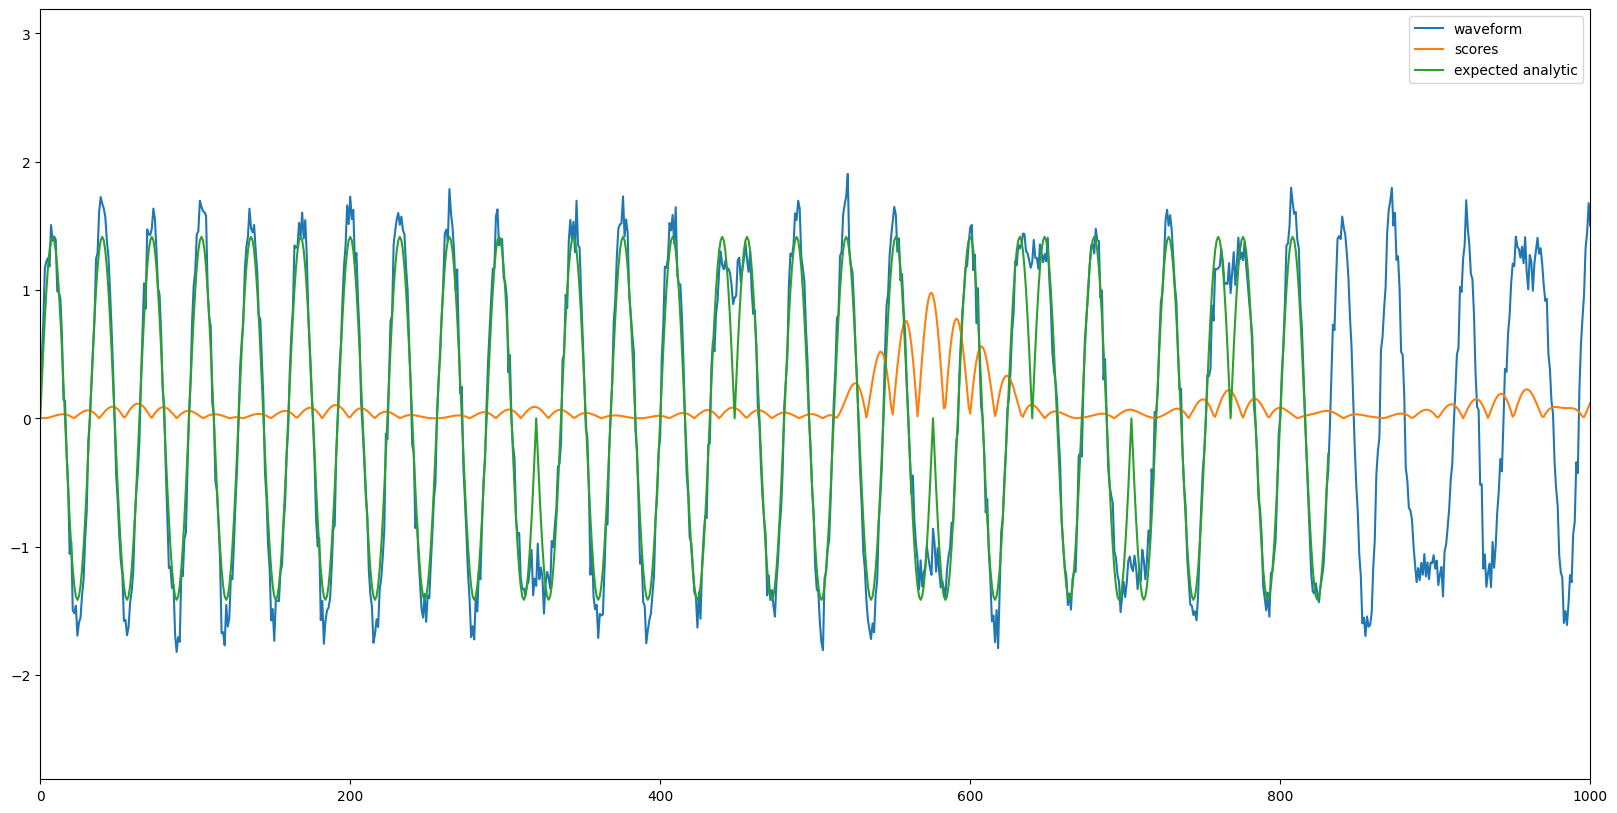

In [22]:
plot_waveform_scores_expected_analytic(*debug_data["no-whatsapp"])

# Con WhatsApp, preambolo trovato
Questo grafico invece rappresenta il preambolo trovato in un audio che è stato salvato da WhatsApp

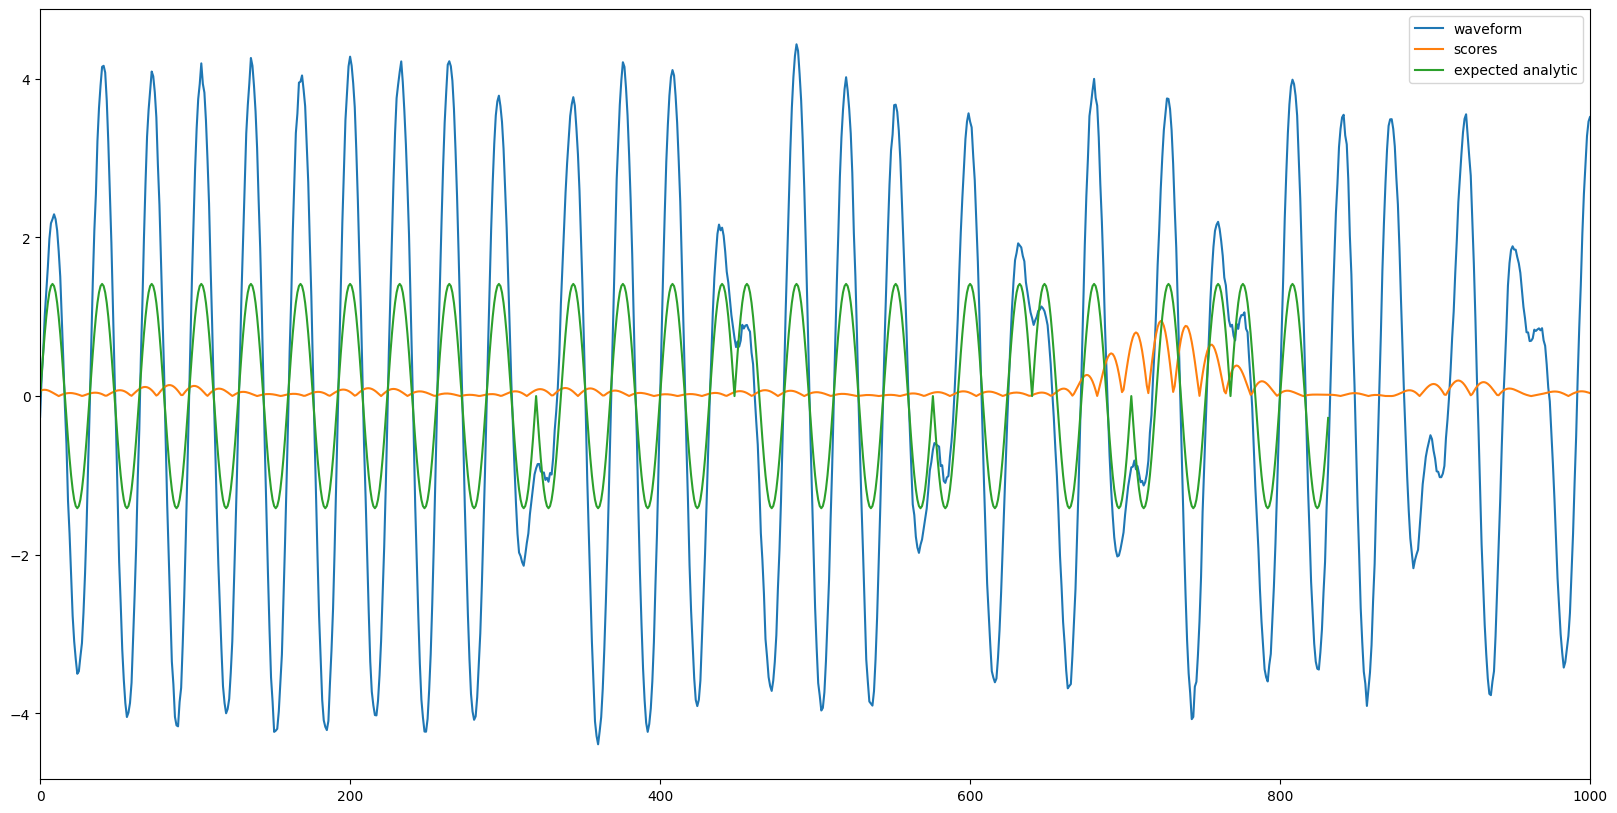

In [23]:
plot_waveform_scores_expected_analytic(*debug_data["whatsapp-detected"])

# Con WhatsApp, preambolo non trovato
IN quest'ultimo grafico invece il preambolo non è proprio stato trovato. Viene quindi mostrato il miglior match

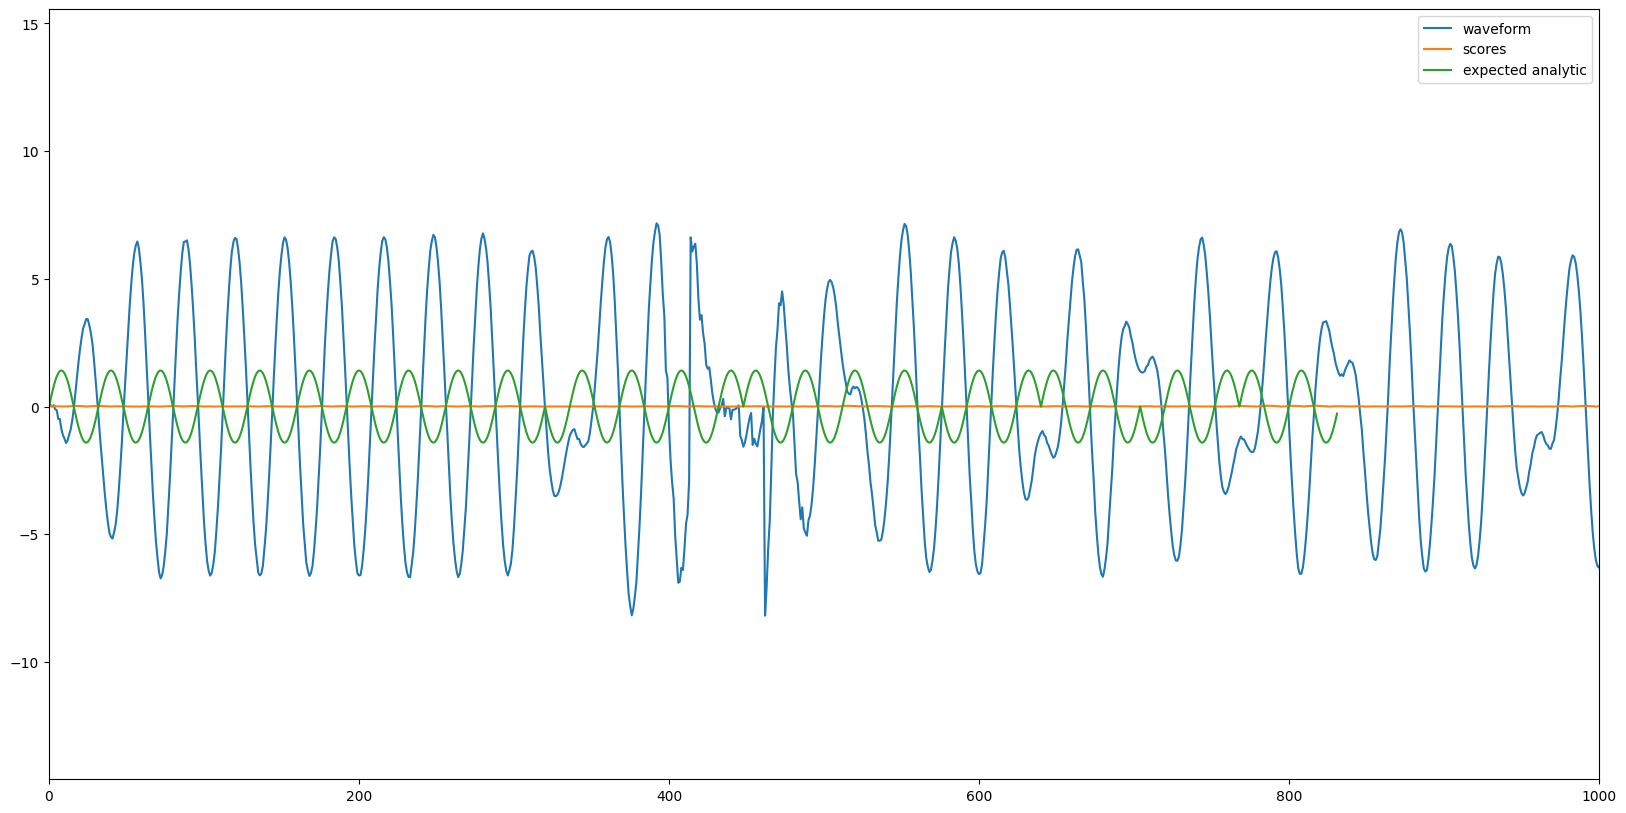

In [24]:
plot_waveform_scores_expected_analytic(*debug_data["whatsapp-not-detected"])